<a href="https://colab.research.google.com/github/agustinAriel/agustinAriel/blob/main/ENTREGA_FINAL_FINAL(esta_si)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ETAPA 1** Recopilación y Preparación de Datos

In [ ]:
import pandas as pd

# 1. Importo los archivos a Colab
ventas = pd.read_csv('ventas.csv')
clientes = pd.read_csv('clientes.csv')
marketing = pd.read_csv('marketing.csv')

# 2. Limpieza: limpieza de columna precios
ventas['precio'] = ventas['precio'].replace('[$,]', '', regex=True).astype(float)

# 3. Calcular ventas totales
ventas['ventas_totales'] = ventas['precio'] * ventas['cantidad']

# 4. Convertir columna de fecha a tipo datetime
ventas['fecha_venta'] = pd.to_datetime(ventas['fecha_venta'], dayfirst=True)

# 5. Extraer el mes y año para agrupar
ventas['mes'] = ventas['fecha_venta'].dt.to_period('M')

# 6. Agrupación: calcular total de ventas por mes
ventas_mensuales = ventas.groupby('mes')['ventas_totales'].sum().reset_index()
ventas_mensuales.columns = ['mes', 'total_ventas']

# 7. Estructuras de datos: lista de productos y diccionario de precios promedio
productos = ventas['producto'].unique().tolist()
precios = ventas.groupby('producto')['precio'].mean().round(2).to_dict()

# 8. Detección de valores nulos y duplicados
nulls_ventas = ventas.isnull().sum()
duplicados_ventas = ventas.duplicated().sum()

# 9. Resultados visibles
print("Ventas mensuales:")
print(ventas_mensuales)

print("\nProductos únicos (muestra):")
print(productos[:5])

print("\nPrecios promedio por producto (muestra):")
print(dict(list(precios.items())[:5]))

print("\nValores nulos por columna:")
print(nulls_ventas)

print(f"\nCantidad de filas duplicadas: {duplicados_ventas}")

clientes = pd.read_csv('/content/clientes.csv')
marketing = pd.read_csv('/content/marketing.csv')

# 2. Exploración inicial de clientes
print("Primeras filas de clientes:")
print(clientes.head(),"\n")

print("\nResumen de nulos en clientes:")
print(clientes.isnull().sum(),"\n")

print(f"\nCantidad de filas duplicadas en clientes: {clientes.duplicated().sum()}","\n")

# 3. Exploración inicial de marketing
print("\nPrimeras filas de marketing:")
print(marketing.head(),"\n")

print("\nResumen de nulos en marketing:")
print(marketing.isnull().sum(),"\n")

print(f"\nCantidad de filas duplicadas en marketing: {marketing.duplicated().sum()}","\n")

Ventas mensuales:
        mes  total_ventas
0   2024-01     129604.99
1   2024-02     118672.44
2   2024-03     136779.15
3   2024-04     144380.10
4   2024-05     143727.25
5   2024-06     108480.17
6   2024-07     116229.97
7   2024-08     119680.15
8   2024-09     115787.85
9   2024-10     112117.13
10  2024-11     119951.79
11  2024-12     117631.94

Productos únicos (muestra):
['Cuadro decorativo', 'Lámpara de mesa', 'Secadora', 'Heladera', 'Horno eléctrico']

Precios promedio por producto (muestra):
{'Adorno de pared': 76.02, 'Alfombra': 73.61, 'Aspiradora': 77.91, 'Auriculares': 76.51, 'Batidora': 77.54}

Valores nulos por columna:
id_venta          0
producto          0
precio            2
cantidad          2
fecha_venta       0
categoria         0
ventas_totales    2
mes               0
dtype: int64

Cantidad de filas duplicadas: 35
Primeras filas de clientes:
   id_cliente               nombre  edad         ciudad  ingresos
0           1      Aloysia Screase    44  Mar del Pl

**ETAPA 2** Preprocesamiento y Limpieza de Datos

In [ ]:
# 1. Agrupar ventas totales por producto
ventas_producto = ventas.groupby('producto')['ventas_totales'].sum().reset_index()

# 2. Calcular el umbral del percentil 75% (top 25%)
umbral = ventas_producto['ventas_totales'].quantile(0.75)

# 3. Seleccionar productos cuyo total vendido supera ese umbral
productos_top = ventas_producto[ventas_producto['ventas_totales'] >= umbral]

# 4. Filtrar el dataset original para quedarnos solo con las filas de esos productos
ventas_alto_rendimiento = ventas[ventas['producto'].isin(productos_top['producto'])]

# 5. Imprimir resultados
print("Productos de alto rendimiento (top 25% de ventas):")
print(productos_top,"\n")

print("\nVentas filtradas:")
print(ventas_alto_rendimiento.head())
#-----------------------------------------------------------------------------------------------------#
# 1. Agrupar por categoría y sumar las ventas totales
ventas_por_categoria = ventas.groupby('categoria')['ventas_totales'].sum().reset_index()

# 2. Renombrar columnas para claridad
ventas_por_categoria.columns = ['categoria', 'ingresos_totales']

# 3. Ordenar de mayor a menor ingresos
ventas_por_categoria = ventas_por_categoria.sort_values(by='ingresos_totales', ascending=False)

# 4. Mostrar resultados
print("Ingresos totales por categoría de producto:")
print(ventas_por_categoria)
#-----------------------------------------------------------------------------------------------------#
# 1. Agrupar por categoría y sumar las ventas totales
ventas_por_categoria = ventas.groupby('categoria')['ventas_totales'].sum().reset_index()

# 2. Renombrar columnas para claridad
ventas_por_categoria.columns = ['categoria', 'ingresos_totales']

# 3. Ordenar de mayor a menor ingresos
ventas_por_categoria = ventas_por_categoria.sort_values(by='ingresos_totales', ascending=False)

# 4. Mostrar resultados
print("Ingresos totales por categoría de producto:")
print(ventas_por_categoria)

Productos de alto rendimiento (top 25% de ventas):
             producto  ventas_totales
3         Auriculares        76468.44
5            Cafetera        59669.54
9   Cuadro decorativo        54297.60
16  Jarrón decorativo        51401.51
19    Lámpara de mesa        84699.15
20         Microondas        72562.89
25           Secadora        53214.24
27         Smartphone        55615.64 


Ventas filtradas:
    id_venta           producto  precio  cantidad fecha_venta  \
0        792  Cuadro decorativo   69.94       5.0  2024-01-02   
1        811    Lámpara de mesa  105.10       5.0  2024-01-02   
2       1156           Secadora   97.96       3.0  2024-01-02   
4       1546           Secadora  106.21       4.0  2024-01-02   
18       794  Jarrón decorativo   96.97       7.0  2024-01-04   

            categoria  ventas_totales      mes  
0          Decoración          349.70  2024-01  
1          Decoración          525.50  2024-01  
2   Electrodomésticos          293.88  2024-01  

In [ ]:
# 1. Integrar ventas y campaña de marketing -> Convertir fechas de marketing a tipo datetime
marketing['fecha_inicio'] = pd.to_datetime(marketing['fecha_inicio'], dayfirst=True)
marketing['fecha_fin'] = pd.to_datetime(marketing['fecha_fin'], dayfirst=True)

# 2. Unir los datasets por columna 'producto'
ventas_marketing = pd.merge(ventas, marketing, on='producto', how='left')

# 3. Verificar coincidencias (muestra)
print("Coincidencias ventas + marketing (muestra):")
print(ventas_marketing[['producto', 'fecha_venta', 'canal', 'costo']].head())

# 4. Crear variable para chequear si la venta ocurrió durante la campaña
ventas_marketing['venta_en_campaña'] = (
    (ventas_marketing['fecha_venta'] >= ventas_marketing['fecha_inicio']) &
    (ventas_marketing['fecha_venta'] <= ventas_marketing['fecha_fin'])
)

# 5. Mostrar resumen del impacto de campaña
impacto = ventas_marketing.groupby('venta_en_campaña')['ventas_totales'].sum().reset_index()
impacto.columns = ['venta_en_campaña', 'ingresos_totales']

print("\nResumen de ingresos según si la venta ocurrió durante campaña:")
print(impacto)

Coincidencias ventas + marketing (muestra):
            producto fecha_venta  canal  costo
0  Cuadro decorativo  2024-01-02   RRSS   5.27
1  Cuadro decorativo  2024-01-02  Email   5.28
2  Cuadro decorativo  2024-01-02     TV   5.30
3    Lámpara de mesa  2024-01-02  Email   5.54
4    Lámpara de mesa  2024-01-02   RRSS   5.88

Resumen de ingresos según si la venta ocurrió durante campaña:
   venta_en_campaña  ingresos_totales
0             False        4025672.30
1              True         423456.49


**ETAPA 3** Análisis de Datos

In [27]:
#Iportamos 🐼
import pandas as pd
import numpy as np

# 1. Estadística Descriptiva
estadisticas = ventas[['precio', 'cantidad', 'ventas_totales']].describe()
print("Resumen estadístico de variables numéricas:")
print(estadisticas)

# 2. Análisis Exploratorio (EDA) – agrupado por producto
ventas_promedio_producto = ventas.groupby('producto')[['precio', 'ventas_totales']].mean().sort_values(by='ventas_totales', ascending=False)
print("\nProductos con mayor venta promedio:")
print(ventas_promedio_producto.head())

# 3. Correlación entre variables
correlacion = ventas[['precio', 'cantidad', 'ventas_totales']].corr()
print("\nMatriz de correlación:")
print(correlacion)

# 4. Consolidación del dataset final
# Conservamos columnas clave + las unidas de marketing
columnas_finales = [
    'id_venta', 'producto', 'precio', 'cantidad', 'ventas_totales',
    'fecha_venta', 'categoria', 'mes',
    'canal', 'costo', 'venta_en_campaña'
]

ventas_final = ventas_marketing[columnas_finales].copy()

# Mostramos una muestra consolidada
print("\nVista previa del dataset final consolidado:")
print(ventas_final.head())

Resumen estadístico de variables numéricas:
            precio     cantidad  ventas_totales
count  3033.000000  3033.000000     3033.000000
mean     75.289034     6.496538      488.968985
std      28.734666     3.457250      334.594511
min      26.000000     1.000000       26.300000
25%      50.020000     3.000000      220.500000
50%      75.270000     7.000000      418.050000
75%     100.040000     9.000000      708.890000
max     124.970000    12.000000     1488.120000

Productos con mayor venta promedio:
                      precio  ventas_totales
producto                                    
Smartphone         81.812157      545.251373
Cuadro decorativo  74.578000      542.976000
Microondas         79.176000      537.502889
Heladera           74.426735      528.864490
Auriculares        76.509252      520.193469

Matriz de correlación:
                  precio  cantidad  ventas_totales
precio          1.000000 -0.001501        0.558799
cantidad       -0.001501  1.000000        0.77

**ETAPA 4** Visualización de Datos

**Visualización con Matplotlib**

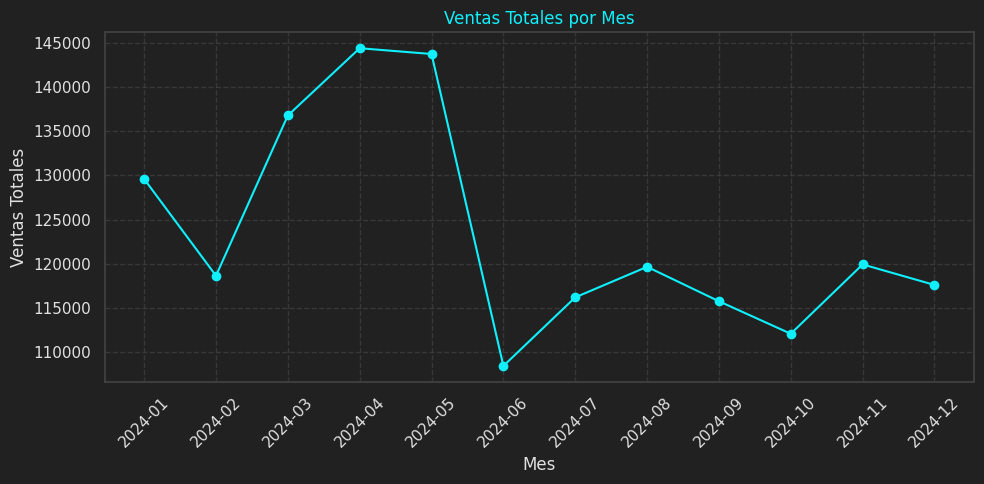

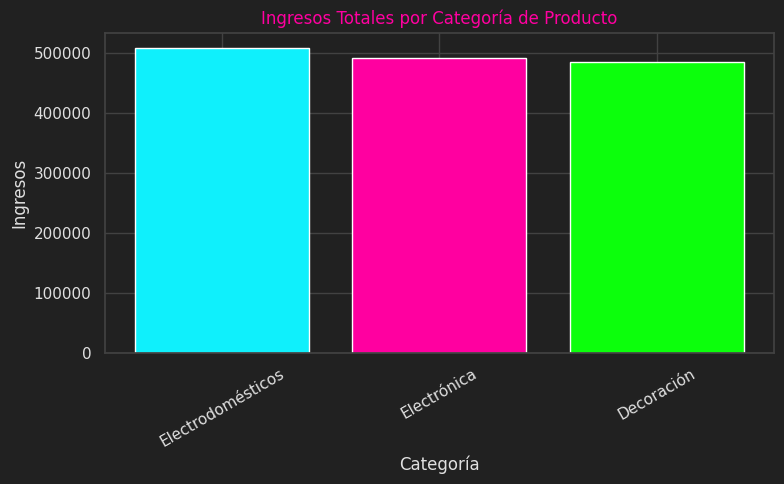

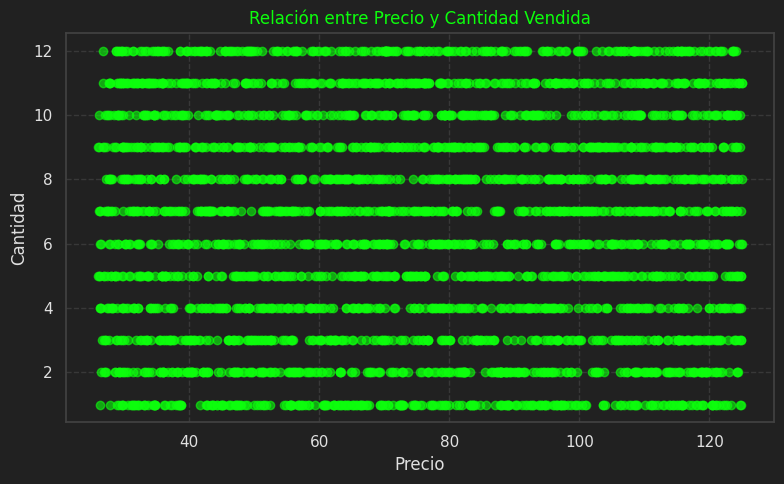

In [34]:
import matplotlib.pyplot as plt

# Definir una secuencia de colores 'cyberpunk' (tomada de la celda de Plotly)
cyberpunk_colors = [
    '#0FF0FC', '#FF00A0', '#0CFF0C', '#FFC800', '#B026FF', '#007FFF', '#FF4B3A',
    '#A0FF00', '#F000FF', '#00FFFF', '#FF8C00', '#FF1493', '#ADFF2F', '#8A2BE2'
]

# Configurar el estilo general de Matplotlib para un aspecto "cyberpunk"
plt.style.use('dark_background') # Fondo oscuro
plt.rcParams['axes.facecolor'] = '#212121' # Fondo del área del gráfico
plt.rcParams['figure.facecolor'] = '#212121' # Fondo de la figura
plt.rcParams['text.color'] = '#E0E0E0' # Color del texto general
plt.rcParams['xtick.color'] = '#E0E0E0' # Color de las etiquetas del eje x
plt.rcParams['ytick.color'] = '#E0E0E0' # Color de las etiquetas del eje y
plt.rcParams['grid.color'] = '#424242' # Color de la cuadrícula
plt.rcParams['axes.edgecolor'] = '#424242' # Color de los bordes de los ejes
plt.rcParams['axes.labelcolor'] = '#E0E0E0' # Color de las etiquetas de los ejes

# 1. Gráfico de líneas
plt.figure(figsize=(10, 5))
plt.plot(ventas_mensuales['mes'].astype(str), ventas_mensuales['total_ventas'], marker='o', color=cyberpunk_colors[0])
plt.title('Ventas Totales por Mes', color=cyberpunk_colors[0])
plt.xlabel('Mes')
plt.ylabel('Ventas Totales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Gráfico de barras
plt.figure(figsize=(8, 5))
# Usar una sub-paleta de colores para las barras si hay más categorías que el tamaño de la paleta
num_categorias_bar = ventas_por_categoria['categoria'].nunique()
bar_colors = cyberpunk_colors[:num_categorias_bar] if num_categorias_bar <= len(cyberpunk_colors) else cyberpunk_colors
plt.bar(ventas_por_categoria['categoria'], ventas_por_categoria['ingresos_totales'], color=bar_colors)
plt.title('Ingresos Totales por Categoría de Producto', color=cyberpunk_colors[1])
plt.xlabel('Categoría')
plt.ylabel('Ingresos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3. Gráfico de Dispersión
plt.figure(figsize=(8, 5))
plt.scatter(ventas['precio'], ventas['cantidad'], alpha=0.6, color=cyberpunk_colors[2])
plt.title('Relación entre Precio y Cantidad Vendida', color=cyberpunk_colors[2])
plt.xlabel('Precio')
plt.ylabel('Cantidad')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Visualización Avanzada con Seaborn**

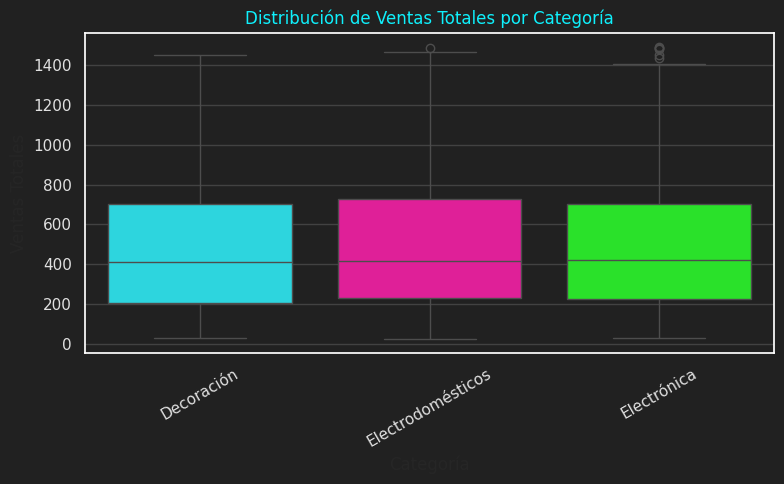

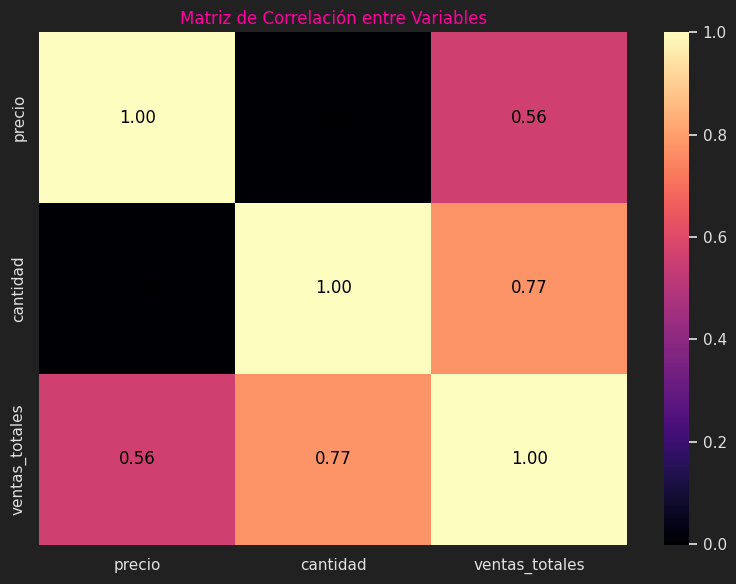

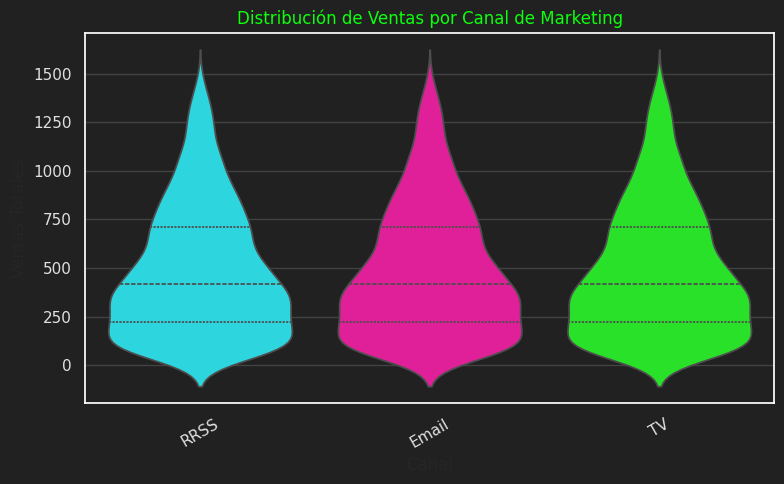

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir una secuencia de colores 'cyberpunk' (tomada de la celda de Plotly)
cyberpunk_colors = [
    '#0FF0FC', '#FF00A0', '#0CFF0C', '#FFC800', '#B026FF', '#007FFF', '#FF4B3A',
    '#A0FF00', '#F000FF', '#00FFFF', '#FF8C00', '#FF1493', '#ADFF2F', '#8A2BE2'
]

# Estilo general para Seaborn
sns.set_theme(style="darkgrid", rc={'axes.facecolor': '#212121', 'figure.facecolor': '#212121', 'text.color': '#E0E0E0', 'xtick.color': '#E0E0E0', 'ytick.color': '#E0E0E0', 'grid.color': '#424242'})

# Crear una paleta de colores personalizada para Seaborn
custom_palette = sns.color_palette(cyberpunk_colors)

# Obtener el número de categorías únicas para el boxplot
num_categorias = ventas['categoria'].nunique()

# 1. Boxplot: distribución de ventas por categoría
plt.figure(figsize=(8, 5))
sns.boxplot(x='categoria', y='ventas_totales', data=ventas, palette=custom_palette[:num_categorias], hue='categoria', legend=False)
plt.title('Distribución de Ventas Totales por Categoría', color='#0FF0FC')
plt.xlabel('Categoría')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2. Heatmap: correlación entre variables numéricas
plt.figure(figsize=(8, 6))
cor_matrix = ventas[['precio', 'cantidad', 'ventas_totales']].corr()
sns.heatmap(cor_matrix, annot=True, cmap="magma", fmt=".2f", annot_kws={"color": "black"})
plt.title('Matriz de Correlación entre Variables', color='#FF00A0')
plt.tight_layout()
plt.show()

# Obtener el número de canales únicos para el violin plot
num_canales = ventas_marketing['canal'].nunique()

# 3. Violin plot: efecto del canal de marketing sobre ventas (solo si hay coincidencia en la unión)
plt.figure(figsize=(8, 5))
sns.violinplot(x='canal', y='ventas_totales', data=ventas_marketing, inner='quartile', palette=custom_palette[:num_canales], hue='canal', legend=False)
plt.title('Distribución de Ventas por Canal de Marketing', color='#0CFF0C')
plt.xlabel('Canal')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Visualización Interactiva con Plotly**

In [30]:
import plotly.express as px

# Asegurarse de que la columna 'mes' esté en formato string
ventas_mensuales['mes_str'] = ventas_mensuales['mes'].astype(str)

# Definir una secuencia de colores 'cyberpunk' (puedes ajustarla a tu gusto)
cyberpunk_colors = [
    '#0FF0FC', '#FF00A0', '#0CFF0C', '#FFC800', '#B026FF', '#007FFF', '#FF4B3A',
    '#A0FF00', '#F000FF', '#00FFFF', '#FF8C00', '#FF1493', '#ADFF2F', '#8A2BE2'
]

# 1. Gráfico interactivo de ventas por mes
fig1 = px.line(
    ventas_mensuales,
    x='mes_str',
    y='total_ventas',
    title='Evolución Mensual de Ventas',
    markers=True,
    template='plotly_dark', # Aplicar tema oscuro
    color_discrete_sequence=[cyberpunk_colors[0]], # Un solo color para la línea
    height=400, # Reducir altura del gráfico
    width=600 # Reducir ancho del gráfico
)
fig1.update_layout(xaxis_title='Mes', yaxis_title='Ventas Totales')
fig1.show()

# 2. Gráfico de barras por categoría
fig2 = px.bar(
    ventas_por_categoria,
    x='categoria',
    y='ingresos_totales',
    title='Ingresos Totales por Categoría',
    color='categoria',
    template='plotly_dark', # Aplicar tema oscuro
    color_discrete_sequence=cyberpunk_colors, # Usar colores ciberpunk
    height=400, # Reducir altura del gráfico
    width=600 # Reducir ancho del gráfico
)
fig2.update_layout(xaxis_title='Categoría', yaxis_title='Ingresos')
fig2.show()

# 3. Gráfico de dispersión: Precio vs Cantidad, con color por canal de marketing
# Filtrar filas que no tengan datos nulos en las columnas clave
ventas_plot = ventas_marketing.dropna(subset=['precio', 'cantidad', 'ventas_totales', 'canal'])

fig3 = px.scatter(
    ventas_plot,
    x='precio',
    y='cantidad',
    size='ventas_totales',
    color='canal',
    hover_data=['producto'],
    title='Relación Precio vs Cantidad (segmentado por Canal)',
    template='plotly_dark', # Aplicar tema oscuro
    color_discrete_sequence=cyberpunk_colors, # Usar colores ciberpunk
    height=400, # Reducir altura del gráfico
    width=600 # Reducir ancho del gráfico
)
fig3.update_layout(xaxis_title='Precio', yaxis_title='Cantidad Vendida')
fig3.show()

Resumen del Proyecto: Análisis de Ventas y Marketing

Este proyecto se ha centrado en analizar datos de ventas, clientes y campañas de marketing para extraer información clave y visualizar tendencias.

    Recopilación y Preparación de Datos (ETAPA 1):
        Se cargaron los datasets de ventas, clientes y marketing.
        Se realizó una limpieza inicial, convirtiendo la columna precio a formato numérico y calculando las ventas_totales.
        Se normalizaron las fechas y se agregaron las ventas por mes.
        Se detectaron valores nulos y duplicados para entender la calidad de los datos.

    Preprocesamiento y Limpieza de Datos (ETAPA 2):
        Se identificaron los productos de alto rendimiento (top 25% en ventas).
        Se agruparon y analizaron los ingresos totales por categoría de producto, identificando las categorías más rentables.
        Se integraron los datos de ventas con las campañas de marketing para evaluar el impacto de las campañas en las ventas.

    Análisis de Datos (ETAPA 3):
        Se obtuvieron estadísticas descriptivas de variables clave como precio, cantidad y ventas_totales.
        Se analizaron los productos con mayor venta promedio.
        Se calculó la matriz de correlación para entender las relaciones entre precio, cantidad y ventas_totales (por ejemplo, la fuerte correlación entre cantidad y ventas totales).
        Se consolidó un dataset final para el análisis integral.

    Visualización de Datos (ETAPA 4):
        Se crearon una variedad de gráficos utilizando Matplotlib, Seaborn y Plotly para presentar los hallazgos de manera efectiva.
        Las visualizaciones incluyen:
            Tendencias de ventas mensuales (línea).
            Ingresos totales por categoría de producto (barras).
            Relación entre precio y cantidad vendida (dispersión).
            Distribución de ventas por categoría (boxplot y violin plot).
            Matriz de correlación entre variables numéricas (heatmap).
            Distribución de ventas por canal de marketing (violin plot).